In [2]:
import xarray as xr
import numpy as np
from datetime import datetime
from calendar import monthrange
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
import random
from datetime import datetime
import metpy
import xskillscore
import os

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13
})

/opt/miniconda3/lib/python3.9/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [6]:
import dask
from dask.distributed import Client, LocalCluster

dask.config.config["distributed"]["dashboard"]["link"] = "{JUPYTERHUB_SERVICE_PREFIX}proxy/{host}:{port}/status"

client = Client(threads_per_worker=1, n_workers=16)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/amahesh/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,
Dashboard: /user/amahesh/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,Workers: 16
Total threads: 16,Total memory: 476.37 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36977,Workers: 16
Dashboard: /user/amahesh/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,Total threads: 16
Started: Just now,Total memory: 476.37 GiB
Comm: tcp://127.0.0.1:38507,Total threads: 1
Dashboard: /user/amahesh/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:37135/status,Memory: 29.77 GiB
Nanny: tcp://127.0.0.1:44021,


In [7]:
#This ensemble has no initial condition perturbations, only multiple checkpoints perturbations
root_dir = "/pscratch/sd/a/amahesh/hens/time_collection/nopert_33multicheckpoint_pert0p35_k1i3_500km_oppositepert_detfix_nodpr_timeevolve_hemisphererescale_target48_20minus20_newseed_repeat_qperturbfix_rankhist_qmin0/"

# Initialize an empty list to store file paths
file_paths = []

# List all subdirectories in the root directory
subdirs = [os.path.join(root_dir, d) for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
zarrs = []
# Check each subdirectory for the 'ensemble.zarr' file
for subdir in subdirs:
    file_path = os.path.join(subdir, "ensemble.zarr")
    #Take every other ensemble member, as there are 2 ensemble members per checkpoint which were duplicated in the run
    ds = xr.open_zarr(file_path).isel(time=20, ensemble=np.arange(0,67,2))[['t2m', 'tcwv', 'u10m', 'v10m']]
    ds['wind_speed10m'] = np.sqrt(ds['u10m']**2 + ds['v10m']**2)
    ds = ds[['t2m', 'tcwv', 'wind_speed10m']]
    zarrs.append(ds)
    


In [8]:
ds = xr.concat(zarrs, dim='initial_time')
ds

<xarray.Dataset> Size: 22GB
Dimensions:        (initial_time: 52, ensemble: 34, lat: 721, lon: 1440)
Coordinates:
  * lat            (lat) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * lon            (lon) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    time           (initial_time) datetime64[ns] 416B 2018-07-15 ... 2018-08-26
Dimensions without coordinates: initial_time, ensemble
Data variables:
    t2m            (initial_time, ensemble, lat, lon) float32 7GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    tcwv           (initial_time, ensemble, lat, lon) float32 7GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    wind_speed10m  (initial_time, ensemble, lat, lon) float32 7GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.10
    config:                 {"weather_model": "dummy_model", "simulation_leng...
    date_created:           2025-03-29T01:08:29.586971
    history:                /global/u2/a/amahesh/hens/earth2mip/earth2mip/tim...
    institution:            NVIDIA
    model:                  dummy_model
    model_str:              None
    time_averaging_window:  
    weather_event:          {"properties": {"name": "global", "start_time": "...

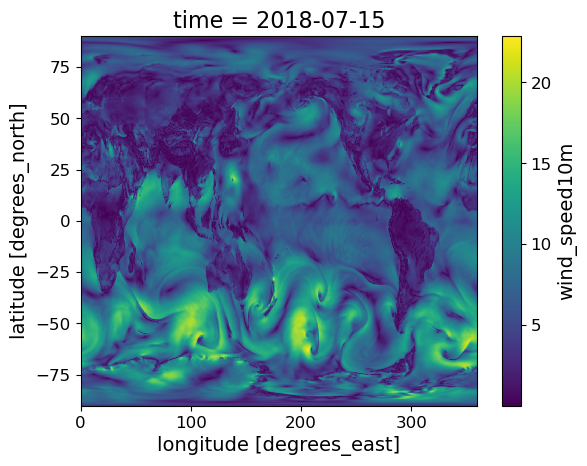

In [9]:
ds['wind_speed10m'].isel(initial_time=0, ensemble=0).plot()

In [10]:
ds = ds.load()

In [ ]:
per_ens = []
np.random.seed(0)
weights = np.cos(np.deg2rad(ds['lat']))
for ensemble_size in range(4, 35, 5):
    sample_var = []
    for trial in range(200):
        sample = np.random.choice(34, size=ensemble_size, replace=True)
        sampled_ds = ds.sel(ensemble=sample)
        sample_var.append(np.sqrt(sampled_ds.var('ensemble', ddof=1).weighted(weights).mean(('lat', 'lon', 'initial_time'))))
    print('done')
    sample_var = xr.concat(sample_var, dim='trial')
    per_ens.append(sample_var)
        

done


In [ ]:
per_ens = xr.concat(per_ens, dim='ensemble_size')


In [ ]:
per_ens.to_netcdf("/pscratch/sd/a/amahesh/temp/per_ens_morevars200trials.nc")

In [8]:
per_ens = xr.open_dataset("/pscratch/sd/a/amahesh/temp/per_ens_morevars200trials.nc")['wind_speed10m']
per_ens

<xarray.DataArray 'wind_speed10m' (ensemble_size: 7, trial: 200)> Size: 6kB
[1400 values with dtype=float32]
Dimensions without coordinates: ensemble_size, trial

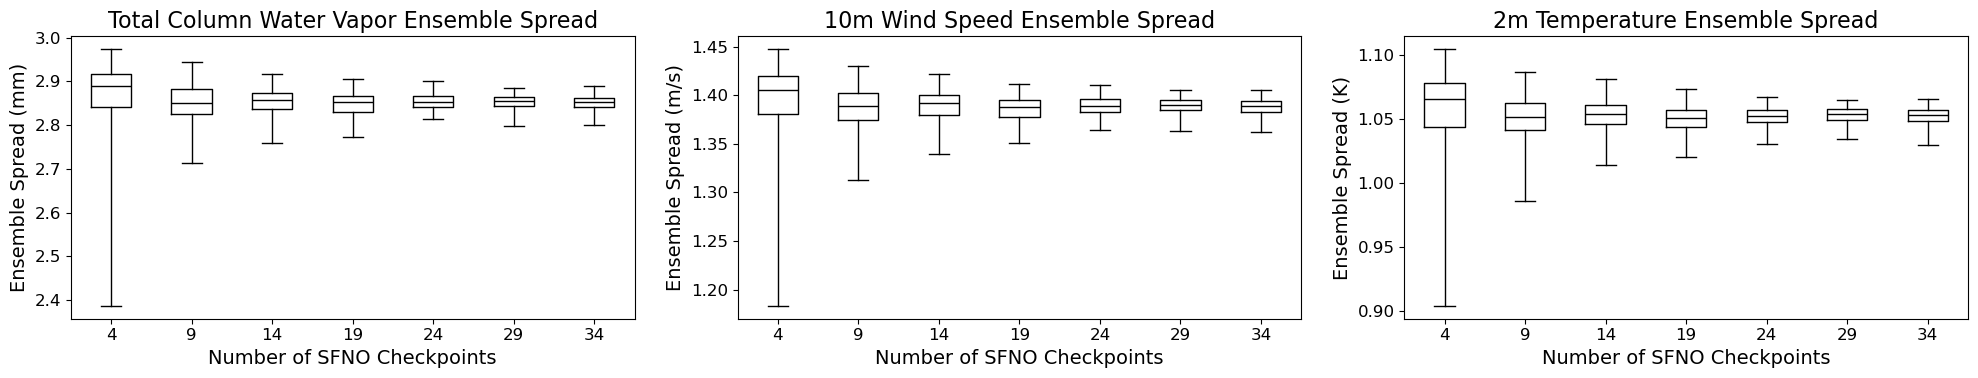

In [33]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20,4))
full_name = {
    'tcwv' : 'Total Column Water Vapor',
    'wind_speed10m': '10m Wind Speed', 
    't2m' : '2m Temperature'
    }
units = {
    'tcwv' : 'mm',
    'wind_speed10m': 'm/s', 
    't2m' : 'K'
    }

# colors={'t2m' : 'green', 
#         'wind_speed10m' : '#835a53',
        
for idx, var in enumerate(['tcwv', 'wind_speed10m', 't2m']):
    per_ens = xr.open_dataset("/pscratch/sd/a/amahesh/temp/per_ens_morevars200trials.nc")[var]
    ax = axs[idx]
    box = ax.boxplot(per_ens.T, showfliers=False,
                     medianprops=dict(color='black'), whis=(0,100))
    ax.set_xlabel("Number of SFNO Checkpoints")
    ax.set_xticks(range(1,8), labels=range(4, 35, 5))
    ax.set_ylabel(f"Ensemble Spread ({units[var]})")
    ax.set_title(f"{full_name[var]} Ensemble Spread")
# plt.ylim((0.95, 1.11))

#Make all elements of the box plot green

plt.tight_layout()
# Adjusting the axes labels and limits
plt.savefig("why_29checkpoints_multivar.pdf")
# Display the plot
plt.show()